get dataset from drive


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !unzip -q "/content/drive/MyDrive/Chilli-leaf-disease-dataset/Chili-Leaf-Disease-Augmented-Dataset.zip" -d "/content/chili_dataset"

# !ls "/content/chili_dataset"

'Chili Leaf Disease Augmented Dataset'


Main

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications.resnet50 import preprocess_input

In [ ]:
data_path = '/content/chili_dataset/Chili Leaf Disease Augmented Dataset'

datagen = ImageDataGenerator(preprocessing_function=preprocess_input, validation_split=0.2) # 12000 images

training_data = datagen.flow_from_directory(data_path, target_size=(224, 224), batch_size=32, class_mode='categorical', subset='training')

validation_data = datagen.flow_from_directory(data_path, target_size=(224, 224), batch_size=32, class_mode='categorical', subset='validation')

print(f"\nCategories found: ")
for i in training_data.class_indices.keys():
  print(i)

Found 9600 images belonging to 6 classes.
Found 2400 images belonging to 6 classes.

Categories found: 
Bacterial Spot
Cercospora Leaf Spot
Curl Virus
Healthy Leaf
Nutrition Deficiency
White spot


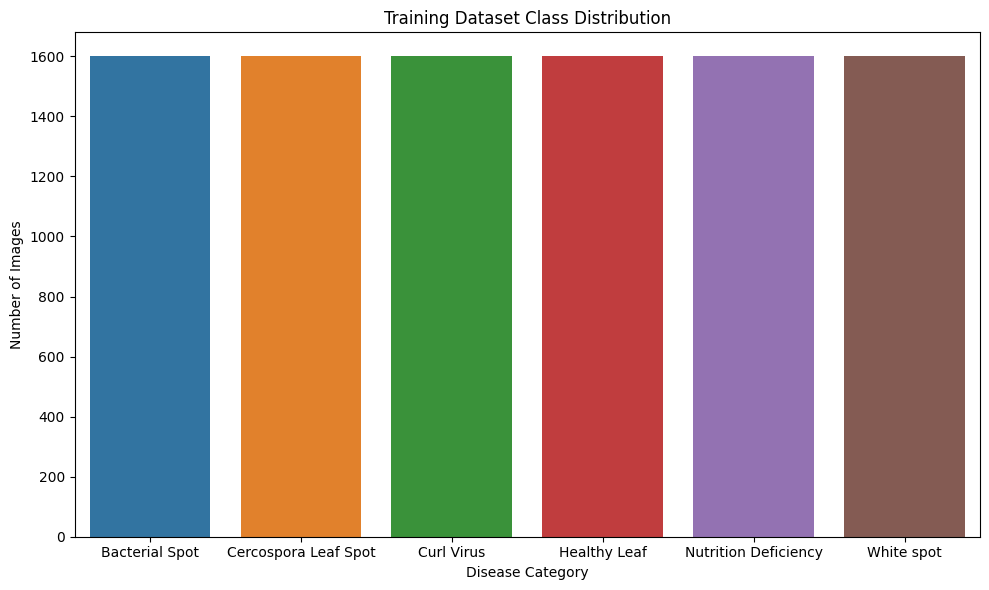

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

class_names = list(training_data.class_indices.keys())
class_counts = np.unique(training_data.classes, return_counts=True)[1]


plt.figure(figsize=(10, 6))
sns.barplot(x=class_names,y=class_counts,  hue=class_names, legend=False)

plt.title('Training Dataset Class Distribution')
plt.xlabel('Disease Category')
plt.ylabel('Number of Images')

plt.tight_layout()
plt.show()

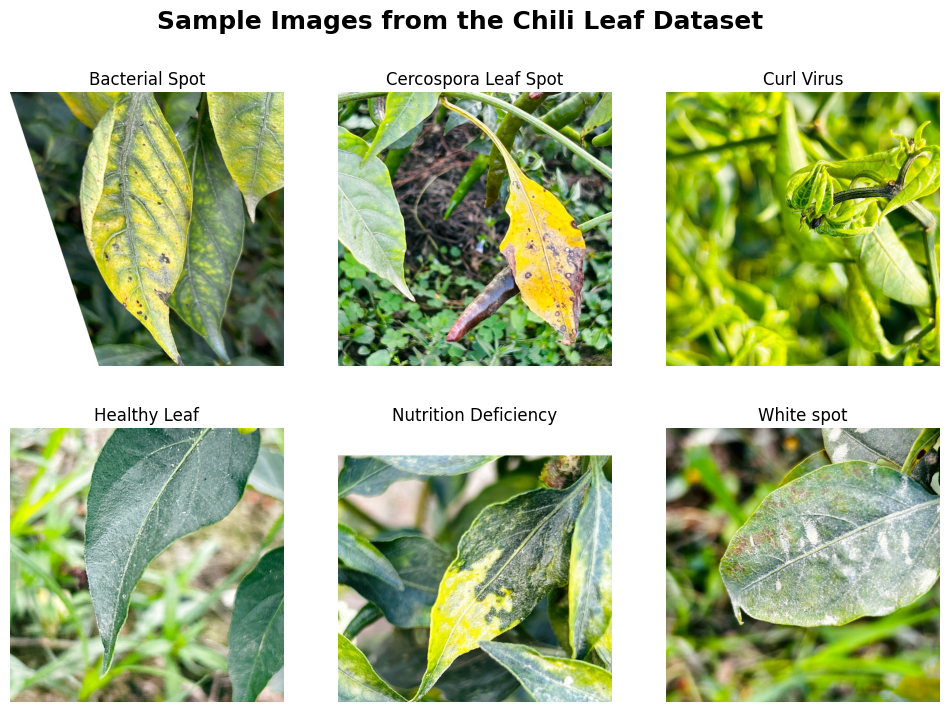

In [ ]:
import os
import random
import matplotlib.image as mpimg

plt.figure(figsize=(12, 8))

for i, category in enumerate(class_names):
    folder_path = os.path.join(data_path, category)

    img_file = random.choice(os.listdir(folder_path))
    img_path = os.path.join(folder_path, img_file)

    img = mpimg.imread(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)

    plt.title(category)
    plt.axis('off')

plt.suptitle('Sample Images from the Chili Leaf Dataset', fontsize=18, fontweight='bold')
plt.show()

In [ ]:
vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

vgg16_base.trainable = False

vgg16_model = Sequential([
    vgg16_base,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

vgg16_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
vgg16_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,558 (56.64 MB)

 Trainable params: 132,870 (519.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
resnet50_base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

resnet50_base.trainable = False

resnet50_model = Sequential([
    resnet50_base,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

resnet50_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
resnet50_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
print("--- Training VGG-16 ---")
vgg_history = vgg16_model.fit(training_data, validation_data=validation_data, epochs=15)

print("--- Training ResNet-50 ---")
resnet_history = resnet50_model.fit(training_data, validation_data=validation_data, epochs=15)

--- Training VGG-16 ---
Epoch 1/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 179s 546ms/step - accuracy: 0.8476 - loss: 0.6431 - val_accuracy: 0.9225 - val_loss: 0.2564
Epoch 2/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 152s 507ms/step - accuracy: 0.9615 - loss: 0.1123 - val_accuracy: 0.9333 - val_loss: 0.2034
Epoch 3/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 139s 465ms/step - accuracy: 0.9773 - loss: 0.0659 - val_accuracy: 0.9379 - val_loss: 0.1960
Epoch 4/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 138s 461ms/step - accuracy: 0.9803 - loss: 0.0555 - val_accuracy: 0.9458 - val_loss: 0.1940
Epoch 5/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 139s 461ms/step - accuracy: 0.9841 - loss: 0.0431 - val_accuracy: 0.9329 - val_loss: 0.2507
Epoch 6/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 138s 459ms/step - accuracy: 0.9843 - loss: 0.0403 - val_accuracy: 0.9546 - val_loss: 0.1950
Epoch 7/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 137s 455ms/step - accuracy: 0.9880 - loss: 0.0302 - val_accuracy: 0.9521 - val_loss: 0.1825
Epoch 8/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 139s 464ms/s

In [ ]:
print("VGG-16 Model Results")
print(f"Final Accuracy: {vgg_history.history['accuracy'][14]*100:.2f}%")
print(f'Final loss: {vgg_history.history['loss'][14]}')
print(f'Final Accuracy with validation data: {vgg_history.history['val_accuracy'][14]*100:.2f}%')
print(f'Final loss with validation data: {vgg_history.history['val_loss'][14]}')

VGG-16 Model Results
Final Accuracy: 98.80%
Final loss: 0.03200652077794075
Final Accuracy with validation data: 94.17%
Final loss with validation data: 0.30678799748420715


In [ ]:
print("Resnet-50 Model Results")
print(f'Final Accuracy: {resnet_history.history['accuracy'][14]*100:.2f}%')
print(f'Final loss: {resnet_history.history['loss'][14]}')
print(f'Final Accuracy with validation data: {resnet_history.history['val_accuracy'][14]*100:.2f}%')
print(f'Final loss with validation data: {resnet_history.history['val_loss'][14]}')

Resnet-50 Model Results
Final Accuracy: 99.05%
Final loss: 0.022321581840515137
Final Accuracy with validation data: 96.83%
Final loss with validation data: 0.19277378916740417


In [ ]:
from google.colab import files

vgg16_model.save('vgg16_chili.keras')
print("Saved VGG-16")

resnet50_model.save('resnet50_chili.keras')
print("Saved ResNet-50")

files.download('vgg16_chili.keras')
files.download('resnet50_chili.keras')

Saved VGG-16
Saved ResNet-50


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

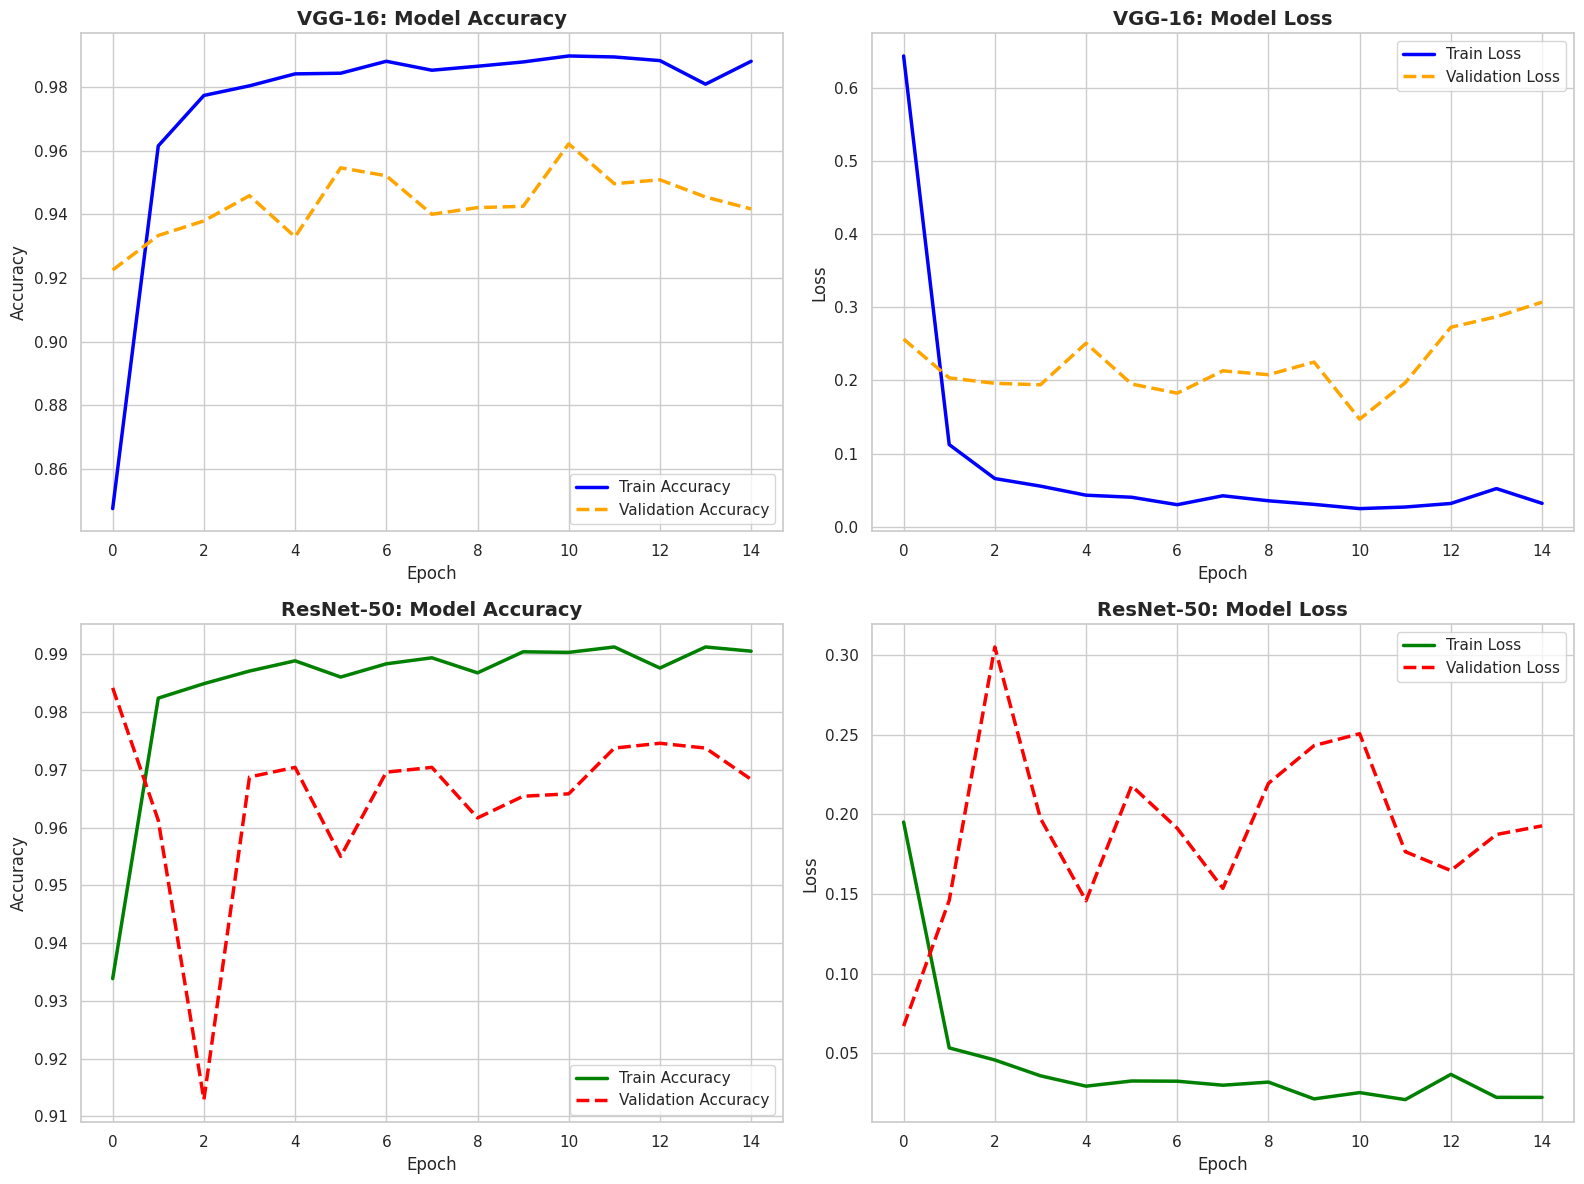

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(vgg_history.history['accuracy'], label='Train Accuracy', linewidth=2.5, color='blue')
axes[0, 0].plot(vgg_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2.5, color='orange', linestyle='--')
axes[0, 0].set_title('VGG-16: Model Accuracy', fontweight='bold', fontsize=14)
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].legend(loc='lower right')

axes[0, 1].plot(vgg_history.history['loss'], label='Train Loss', linewidth=2.5, color='blue')
axes[0, 1].plot(vgg_history.history['val_loss'], label='Validation Loss', linewidth=2.5, color='orange', linestyle='--')
axes[0, 1].set_title('VGG-16: Model Loss', fontweight='bold', fontsize=14)
axes[0, 1].set_ylabel('Loss', fontsize=12)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].legend(loc='upper right')

axes[1, 0].plot(resnet_history.history['accuracy'], label='Train Accuracy', linewidth=2.5, color='green')
axes[1, 0].plot(resnet_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2.5, color='red', linestyle='--')
axes[1, 0].set_title('ResNet-50: Model Accuracy', fontweight='bold', fontsize=14)
axes[1, 0].set_ylabel('Accuracy', fontsize=12)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].legend(loc='lower right')

axes[1, 1].plot(resnet_history.history['loss'], label='Train Loss', linewidth=2.5, color='green')
axes[1, 1].plot(resnet_history.history['val_loss'], label='Validation Loss', linewidth=2.5, color='red', linestyle='--')
axes[1, 1].set_title('ResNet-50: Model Loss', fontweight='bold', fontsize=14)
axes[1, 1].set_ylabel('Loss', fontsize=12)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=300)
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

cm_datagen = ImageDataGenerator(preprocessing_function=preprocess_input, validation_split=0.2)

cm_generator = cm_datagen.flow_from_directory(
    data_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

y_true = cm_generator.classes
class_names = list(cm_generator.class_indices.keys())

Found 2400 images belonging to 6 classes.


75/75 ━━━━━━━━━━━━━━━━━━━━ 28s 367ms/step
75/75 ━━━━━━━━━━━━━━━━━━━━ 27s 361ms/step


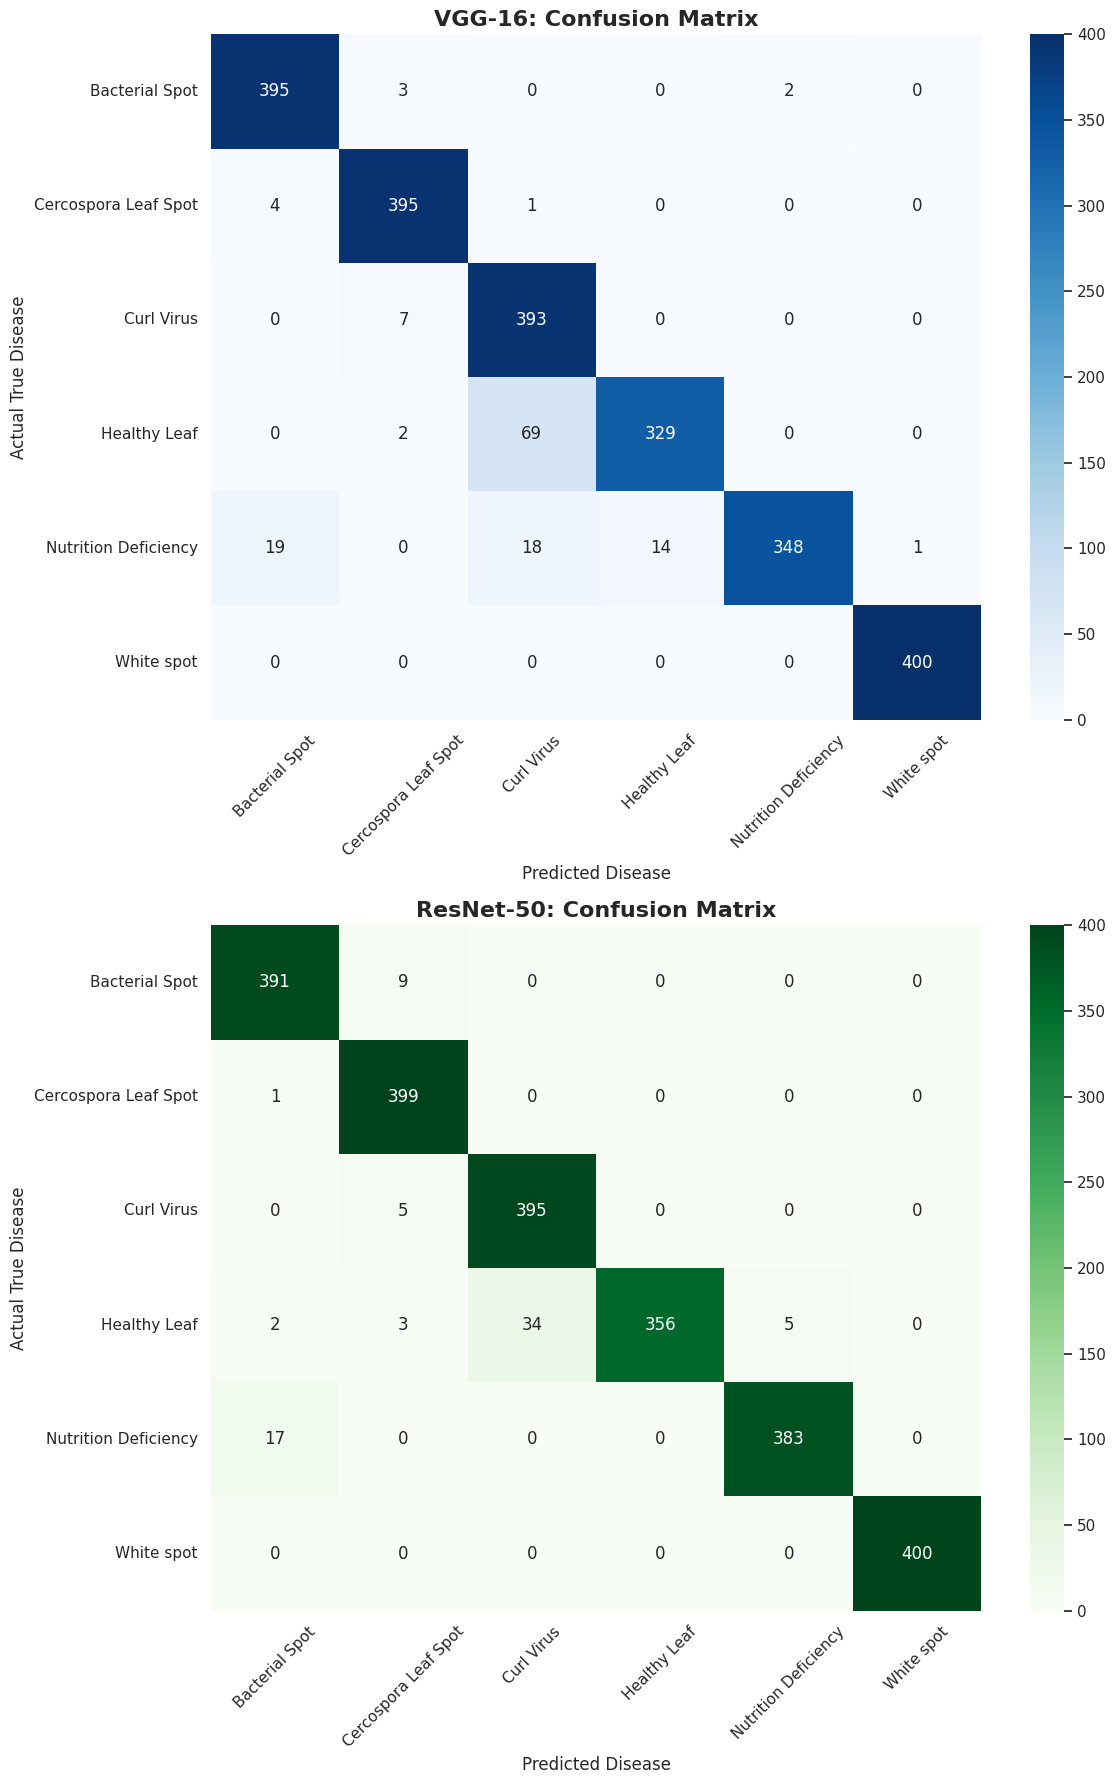

In [ ]:
vgg_predictions = vgg16_model.predict(cm_generator)
y_pred_vgg = np.argmax(vgg_predictions, axis=1)

resnet_predictions = resnet50_model.predict(cm_generator)
y_pred_resnet = np.argmax(resnet_predictions, axis=1)

fig, axes = plt.subplots(2, 1, figsize=(12, 18))

cm_vgg = confusion_matrix(y_true, y_pred_vgg)
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('VGG-16: Confusion Matrix', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Actual True Disease', fontsize=12)
axes[0].set_xlabel('Predicted Disease', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)


cm_resnet = confusion_matrix(y_true, y_pred_resnet)
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('ResNet-50: Confusion Matrix', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Actual True Disease', fontsize=12)
axes[1].set_xlabel('Predicted Disease', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('both_confusion_matrices.png', dpi=300)
plt.show()